# 01 · Documentação da base e decomposição STL
**Disciplina:** Séries Temporais · **Grupo 4** (modelo de especialização: **MLP Regressor**) · **Base analisada:** Daily Delhi Climate (base do Grupo 1)

Este notebook documenta a base, registra as decisões de limpeza e interpreta a decomposição STL. Todas as saídas abaixo foram
geradas pela execução real dos códigos de `src/` (nenhum número foi digitado à mão).

**Escopo.** Esta entrega trata **somente da base do Grupo 1**. As outras quatro bases do enunciado não fazem parte deste arquivo.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
import numpy as np, pandas as pd
import trabalhoseries_redeneural.src.tsutils_delhi as tu
import trabalhoseries_redeneural.src.plots_delhi as pl
warnings.filterwarnings('ignore')
raw = tu.load_raw()
D = tu.clean(raw)
print(f'Arquivo: datasets/DailyDelhiClimateTest.csv | {raw.shape[0]} linhas x {raw.shape[1]} colunas')
display(raw.head())

Arquivo: datasets/DailyDelhiClimateTest.csv | 114 linhas x 5 colunas


,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.91,85.87,2.743,59
1,2017-01-02,18.5,77.22,2.894,1018
2,2017-01-03,17.11,81.89,4.017,1018
3,2017-01-04,18.7,70.05,4.545,1016
4,2017-01-05,18.39,74.94,3.3,1014


## 1. Ficha da base e dicionário de variáveis
| Item | Descrição |
|---|---|
| Nome | *Daily Delhi Climate* (arquivo congelado `DailyDelhiClimateTest.csv`, usado sem alteração no disco) |
| Fonte | Conjunto público "Daily Delhi Climate" (Kaggle). A descrição do conjunto indica origem na API Weather Underground. **A procedência exata deve ser confirmada na página do conjunto**; este trabalho não a verificou de forma independente. |
| Local | Nova Délhi, Índia |
| Período | 01/01/2017 a 24/04/2017 (114 dias) |
| Frequência | Diária, regular |
| Alvo | `meantemp` - temperatura média diária (°C) |
| Horizonte | **h = 1 dia** (a origem *t* prevê o dia *t+1*) |

In [2]:
dic = pd.DataFrame([
 ['date',         'data (dia)',                         '-',    'calendário',          'Conhecida antecipadamente (também a do dia-alvo)'],
 ['meantemp',     'temperatura média diária (ALVO)',     '°C',   'alvo',                'Só até a origem t (lags/médias). O valor de t+1 é o que se prevê'],
 ['humidity',     'umidade relativa média diária',       '%',    'exógena observada',   'NÃO é conhecida em t+1: entra apenas defasada (t, t-1, t-2)'],
 ['wind_speed',   'velocidade média do vento',           'km/h (conforme a documentação do conjunto)', 'exógena observada', 'NÃO é conhecida em t+1: entra apenas defasada'],
 ['meanpressure', 'pressão atmosférica média',           'hPa (conforme a documentação do conjunto)',  'exógena observada', 'NÃO é conhecida em t+1: entra apenas defasada (após correção de erro)'],
], columns=['variável','significado','unidade','tipo','disponibilidade no momento da previsão'])
display(dic)

,variável,significado,unidade,tipo,disponibilidade no momento da previsão
0,date,data (dia),-,calendário,Conhecida antecipadamente (também a do dia-alvo)
1,meantemp,temperatura média diária (ALVO),°C,alvo,Só até a origem t (lags/médias). O valor de t+1 é o que se prevê
2,humidity,umidade relativa média diária,%,exógena observada,"NÃO é conhecida em t+1: entra apenas defasada (t, t-1, t-2)"
3,wind_speed,velocidade média do vento,km/h (conforme a documentação do conjunto),exógena observada,NÃO é conhecida em t+1: entra apenas defasada
4,meanpressure,pressão atmosférica média,hPa (conforme a documentação do conjunto),exógena observada,NÃO é conhecida em t+1: entra apenas defasada (após correção de erro)


## 2. Qualidade dos dados: ausentes, duplicidades, irregularidade temporal e atípicos

In [3]:
display(tu.quality_report(raw))
display(raw.describe().T)

,checagem,resultado
0,observações,114
1,período,2017-01-01 a 2017-04-24
2,datas duplicadas,0
3,datas faltantes na grade diária,0
4,datas fora de ordem,0
5,ausentes em meantemp,0
6,ausentes em humidity,0
7,ausentes em wind_speed,0
8,ausentes em meanpressure,0


,count,mean,min,25%,50%,75%,max,std
date,114,2017-02-26 12:00:00,2017-01-01 00:00:00,2017-01-29 06:00:00,2017-02-26 12:00:00,2017-03-26 18:00:00,2017-04-24 00:00:00,NaN
meantemp,114,21.71,11,16.44,19.88,27.71,34.5,6.36
humidity,114,56.26,17.75,39.62,57.75,71.9,95.83,19.07
wind_speed,114,8.144,1.388,5.564,8.069,10.07,19.31,3.588
meanpressure,114,1004,59,1007,1013,1017,1023,89.47


,variavel,base,data,valor,z_robusto
0,meantemp,diferença,2017-01-26,16.18,-3.5
1,meanpressure,nível,2017-01-01,59,-150
2,meanpressure,diferença,2017-01-02,1018,531.1
3,meanpressure,diferença,2017-02-20,1005,-4.036


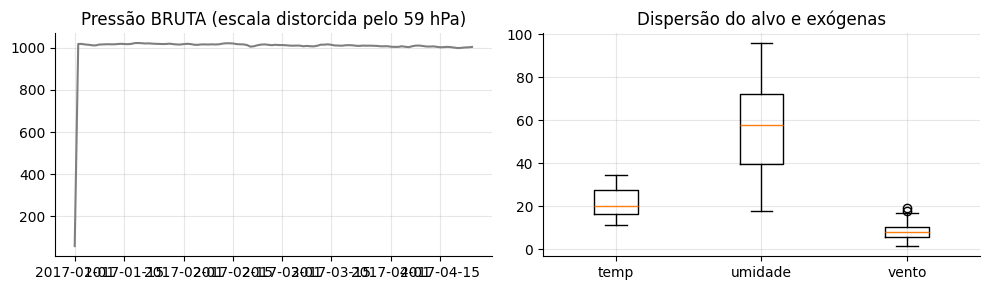

In [4]:
out = tu.outlier_table(raw)
display(out)
pl.raw_pressure(raw)

### Decisões de limpeza (e justificativas)
1. **Pressão de 59,0 hPa em 01/01/2017** é fisicamente impossível ao nível do solo (as demais observações ficam em torno de 1000 hPa).
   O valor distorcia a escala da variável (desvio-padrão da pressão bruta ≈ 89 hPa) e **não havia sido detectado** na entrega original.
   → substituído por NaN e preenchido pelo valor do dia seguinte (única linha afetada; é a 1ª observação, anterior a qualquer origem de previsão ou de teste).
2. **Queda de pressão em 20/02/2017 e variação de temperatura em 26/01/2017** foram sinalizadas pelo escore z robusto, mas são **variações meteorológicas plausíveis** (frentes, dias frios).
   → **mantidas** (remover eventos reais enviesaria o erro de teste para baixo).
3. **Sem duplicidades, sem datas faltantes, sem ausentes** → nenhuma imputação adicional, nenhuma regularização necessária.
4. **Sem transformação do alvo** (nível em °C). A diferenciação é tratada na modelagem (notebook 02).

linhas corrigidas: 1 | pressão corrigida em 01/01: 1018.28


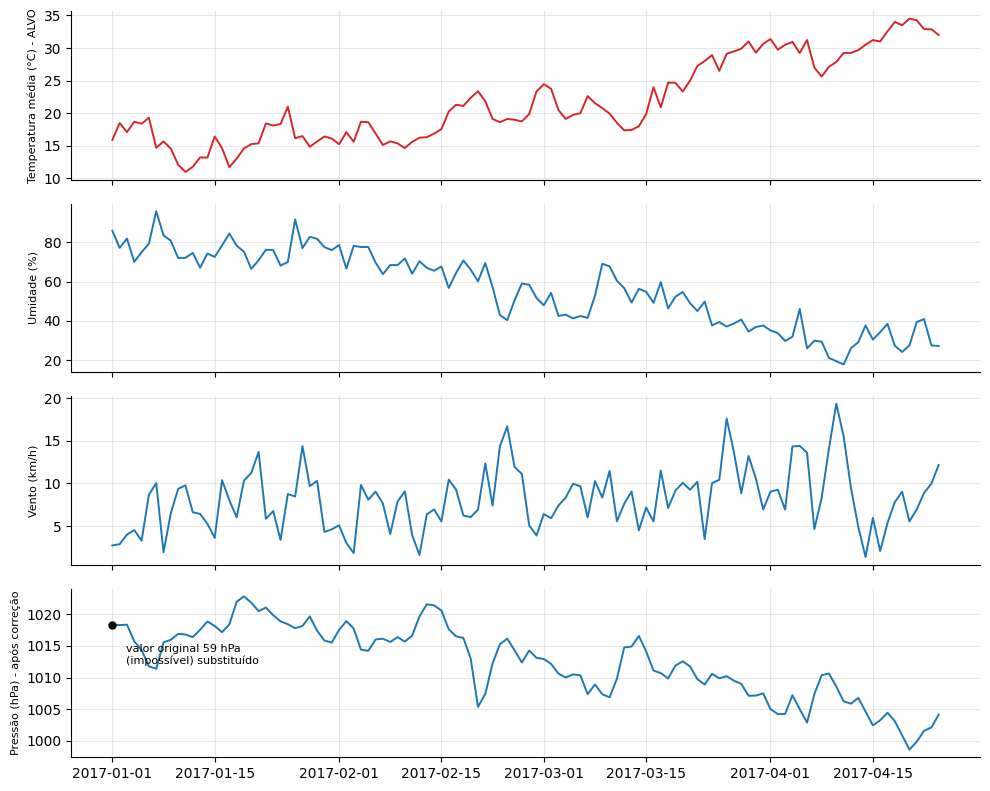

In [5]:
print('linhas corrigidas:', int(D['pressure_corrected'].sum()), '| pressão corrigida em 01/01:', round(D.loc[0,'meanpressure'],2))
pl.series_overview(D)

## 3. Autocorrelação e relação das exógenas com o alvo
A forte inércia da temperatura diária define o desafio: qualquer modelo precisa superar a **persistência** (prever amanhã = hoje).

In [6]:
y = D['meantemp'].values
ac = pd.DataFrame({'ACF do nível': tu.acf(y, 7), 'ACF da diferença (Δy)': tu.acf(np.diff(y), 7)}, index=range(8))
display(ac.round(3))
# relação das exógenas de HOJE com a MUDANÇA de amanhã (o que de fato ajudaria a prever)
dy_next = D['meantemp'].shift(-1) - D['meantemp']
rel = pd.DataFrame({c: [D[c].corr(dy_next), D[c].diff().corr(dy_next)] for c in ['humidity','wind_speed','meanpressure']},
                   index=['corr(x_t , Δy_{t+1})', 'corr(Δx_t , Δy_{t+1})']).T
display(rel.round(3))

,ACF do nível,ACF da diferença (Δy)
0,1,1
1,0.949,-0.129
2,0.909,0.006
3,0.865,0.018
4,0.819,-0.152
5,0.782,-0.063
6,0.753,-0.018
7,0.717,-0.085


,"corr(x_t , Δy_{t+1})","corr(Δx_t , Δy_{t+1})"
humidity,0.008,0.237
wind_speed,-0.086,-0.19
meanpressure,0.158,0.022


**Leitura.** A ACF do nível decai muito devagar (≈ 0,95 no lag 1): a série é dominada por uma tendência, não estacionária em nível.
Já a ACF da primeira diferença é pequena (|ρ| ≤ 0,15 até o lag 7, com lag 1 = −0,13): a **mudança diária é pouco previsível a partir do próprio passado**.
As correlações das exógenas com a mudança de amanhã são fracas (|r| ≤ 0,24; a maior é entre a *variação* da umidade de hoje e Δy de amanhã, ≈ 0,24, o único sinal que merece atenção), o que antecipa que o ganho possível sobre a persistência será pequeno.
Isso motiva (i) prever Δy além do nível como opção de hiperparâmetro e (ii) a comparação obrigatória com a persistência.

## 4. Decomposição STL (Cleveland et al., 1990)
Implementação própria (`tsutils.stl`), testada com séries sintéticas de componentes conhecidos (`tests/test_core.py`).
**Período = 7**: com apenas 114 dias (**menos de um ciclo anual**), a única sazonalidade estimável é a semanal. Uma sazonalidade anual **não é identificável** nesta base.
Parâmetros: janela sazonal `ns=13` (≥ nº de ciclos, aproxima uma sazonalidade estável), janela de tendência `nt=21` (escala de ~3 semanas, para ler fases e não ruído).

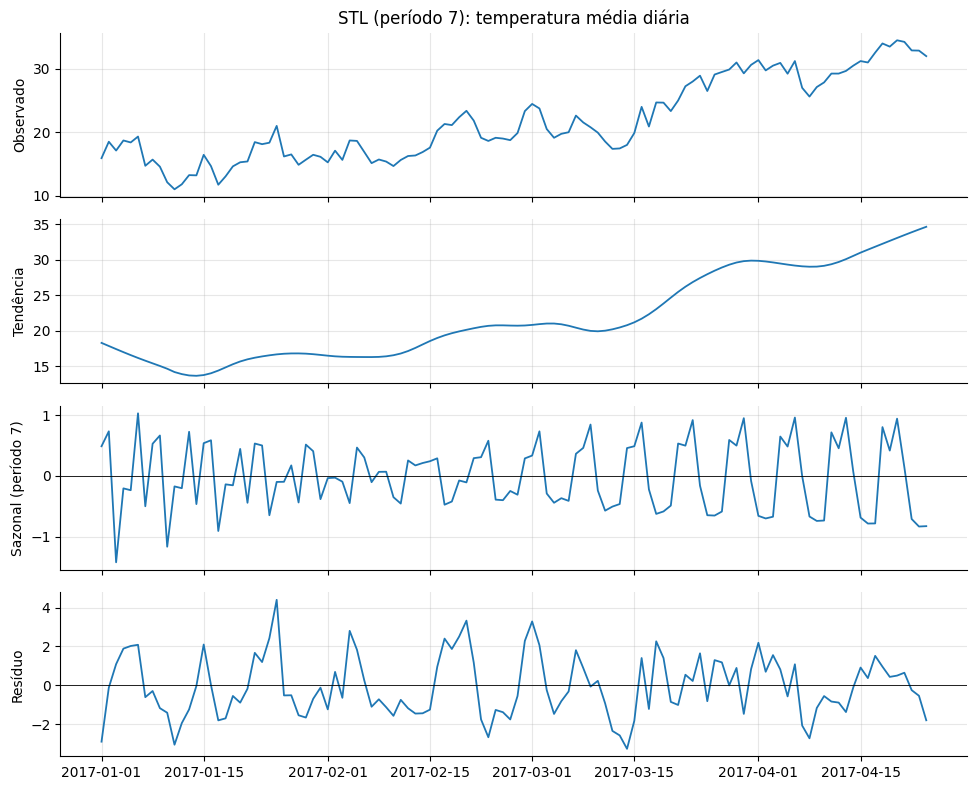

In [7]:
dec = tu.stl(y, 7, seasonal=13, trend=21)
assert np.allclose(dec['trend'] + dec['seasonal'] + dec['resid'], y)
pl.stl_panel(D['date'], y, dec, 'STL (período 7): temperatura média diária')

### 4.1 Tendência: fases de crescimento, queda e estabilidade

,inicio,fim,dias,fase,trend_inicio,trend_fim,variacao,inclinacao_media
0,2017-01-01,2017-01-14,14,queda,18.32,13.69,-4.62,-0.36
1,2017-01-15,2017-01-25,11,crescimento,13.79,16.7,2.91,0.29
2,2017-01-26,2017-02-08,14,estabilidade,16.79,16.35,-0.44,-0.03
3,2017-02-09,2017-02-22,14,crescimento,16.43,20.57,4.14,0.32
4,2017-02-23,2017-03-11,17,estabilidade,20.71,20.03,-0.68,-0.04
5,2017-03-12,2017-04-24,44,crescimento,20.22,34.62,14.4,0.33


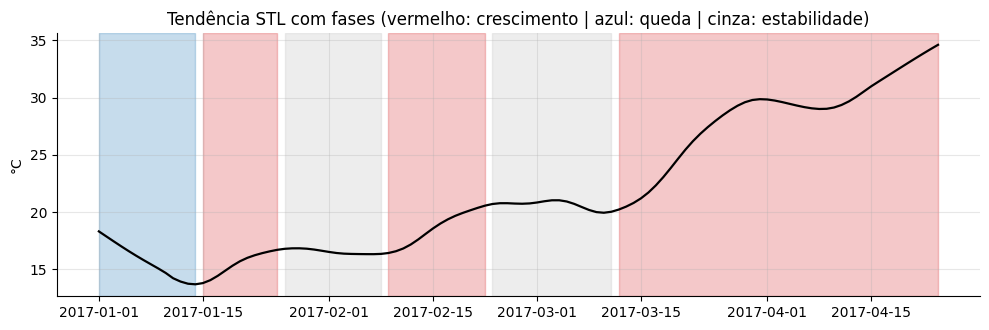

In [8]:
phases = tu.trend_phases(D['date'], dec['trend'], thr=0.10, min_len=7)
tab = phases.copy()
tab['inicio'] = tab['inicio'].dt.date; tab['fim'] = tab['fim'].dt.date
display(tab.round(2))
pl.trend_phases(D['date'], dec['trend'], phases)

**Interpretação da tendência.** Em janeiro há uma **queda** até meados do mês (o mínimo da tendência fica por volta de 14 °C), seguida de recuperação curta;
depois vêm períodos de **estabilidade** (final de janeiro/início de fevereiro e final de fevereiro/início de março, em torno de 16-20 °C) alternando com **crescimento** em meados de fevereiro.
A partir de **12/03** inicia-se um **crescimento contínuo** que dura até o fim da amostra (a tendência sobe de ~20 °C para ~35 °C): é a chegada do verão.
Pontas da série têm incerteza maior (a STL suaviza com menos vizinhos nos extremos), então a "queda" inicial deve ser lida com cautela.

**Consequência para a modelagem:** o período de teste (abril) está em **fase de aquecimento acelerado**, com valores acima de tudo o que o treino viu
(36% dos alvos de teste excedem o máximo do treino, 31,4 °C). Isso penaliza modelos que não extrapolam (árvores) e justifica olhar para a *variação* diária.

### 4.2 Sazonalidade (semanal) e resíduo; força da sazonalidade
Força conforme Hyndman & Athanasopoulos (*Forecasting: Principles and Practice*): **F = max(0, 1 − Var(R) / Var(S + R))**, com S sazonal e R resíduo.
Valores perto de 1 indicam sazonalidade forte; perto de 0, fraca. O mesmo cálculo com a tendência dá a **força da tendência**.

In [9]:
fs, ft = tu.strength(dec)
share = pd.Series({'tendência': np.var(dec['trend'])/np.var(y), 'sazonal (m=7)': np.var(dec['seasonal'])/np.var(y), 'resíduo': np.var(dec['resid'])/np.var(y)})
print(f'Força da sazonalidade (m=7): {fs:.3f}')
print(f'Força da tendência          : {ft:.3f}')
display(share.rename('fração da variância de y').to_frame().round(4))
lbr = tu.ljung_box(dec['resid'], [5, 10])
print('Resíduo STL: ACF(1) = %.2f | Ljung-Box p(5) = %.1e, p(10) = %.1e' % (tu.acf(dec['resid'], 1)[1], lbr.p_valor[0], lbr.p_valor[1]))
print('amplitude do componente sazonal (°C):', round(dec['seasonal'].min(),2), 'a', round(dec['seasonal'].max(),2), '| desvio-padrão do resíduo:', round(dec['resid'].std(),2))
dias = pd.DataFrame({'dia da semana': D['date'].dt.day_name().iloc[:7].values, 'efeito sazonal (°C)': dec['seasonal'][:7]})
display(dias.round(2))

Força da sazonalidade (m=7): 0.124
Força da tendência          : 0.941
Resíduo STL: ACF(1) = 0.52 | Ljung-Box p(5) = 6.0e-12, p(10) = 2.5e-14
amplitude do componente sazonal (°C): -1.43 a 1.03 | desvio-padrão do resíduo: 1.54


,fração da variância de y
tendência,0.9059
sazonal (m=7),0.0075
resíduo,0.0594


,dia da semana,efeito sazonal (°C)
0,Sunday,0.49
1,Monday,0.74
2,Tuesday,-1.43
3,Wednesday,-0.21
4,Thursday,-0.24
5,Friday,1.03
6,Saturday,-0.5


In [10]:
# Robustez da conclusão: força da sazonalidade para outras janelas de suavização e para STL robusta
rows = []
for ns in (7, 13, 25):
    for nt in (13, 21, 31):
        d_ = tu.stl(y, 7, seasonal=ns, trend=nt); a, b = tu.strength(d_)
        rows.append((ns, nt, a, b))
sens = pd.DataFrame(rows, columns=['janela sazonal ns', 'janela tendência nt', 'força sazonal', 'força tendência'])
display(sens.round(3))
dr = tu.stl(y, 7, seasonal=13, trend=21, robust=True)
print('STL robusta (ns=13, nt=21): força sazonal = %.3f | força tendência = %.3f' % tu.strength(dr))

STL robusta (ns=13, nt=21): força sazonal = 0.110 | força tendência = 0.937


,janela sazonal ns,janela tendência nt,força sazonal,força tendência
0,7,13,0.365,0.972
1,7,21,0.274,0.951
2,7,31,0.173,0.923
3,13,13,0.182,0.965
4,13,21,0.124,0.941
5,13,31,0.087,0.916
6,25,13,0.146,0.963
7,25,21,0.103,0.939
8,25,31,0.074,0.915


**Interpretação da sazonalidade e do resíduo.**
- A **tendência explica ~91% da variância** da série (força 0,94); a sazonalidade semanal explica menos de 1% e tem **força ≈ 0,12 (fraca)**.
  A conclusão é robusta: a força sazonal fica entre ~0,07 e ~0,37 em toda a grade de janelas e ≈ 0,11 na STL robusta, sempre abaixo de qualquer limiar usual de "sazonalidade forte" (≈ 0,64).
- O "efeito por dia da semana" tem amplitude de ~2,5 °C pico a pico, mas com 16 ciclos e desvio-padrão do resíduo ≈ 1,5 °C isso é **compatível com ruído**; não há mecanismo físico para um ciclo de 7 dias na temperatura de Délhi.
  (O ciclo semanal que o código original criava com `dayofweek` seria, portanto, ruído como feature.)
- O **resíduo** concentra ~6% da variância (desvio-padrão ≈ 1,5 °C) e **não é ruído branco** (ACF(1) ≈ 0,52; Ljung-Box com p < 0,001): ele contém **episódios meteorológicos de poucos dias** (oscilações visíveis no painel). Isso justifica o uso de lags curtos como features, mas parte dessa memória já é absorvida pela persistência/AR dos modelos (os resíduos de *previsão* do notebook 03 não têm autocorrelação). A STL é uma decomposição *dentro da amostra* e usa o futuro da janela de suavização, portanto serve para entender a série, nunca para gerar features de previsão.
- **Limitação declarada:** a sazonalidade anual, a mais relevante para clima, **não pode ser estimada** com 114 dias. As features `sin/cos` do dia do ano capturam apenas o trecho inicial do ciclo (comportam-se como uma rampa) e não devem ser lidas como "sazonalidade aprendida".

**Impacto nas decisões seguintes:** (i) Holt-Winters deve preferir a versão **sem** componente sazonal (confirmado na busca do notebook 02); (ii) o período sazonal m=7 no SARIMAX/HW é testado, mas esperado como irrelevante;
(iii) a previsão será avaliada contra a **persistência**, a referência natural para uma série com ACF(1)=0,95.